In [11]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
import json
import random
import time 
import matplotlib.patches as mpatches
from human_ai import *
from MIP import StrategyMIP
from utils import *
from model.mallows import Mallows
from human_ai import *

In [36]:
m = 10
k = 3
pi_h = [i + 1 for i in range(10)]
pi_a_aligned = [i + 1 for i in range(10)]
pi_a_misaligned = [i + 1 for i in range(3)] + [10 - i for i in range(7)]
u = [10 - i for i in range(10)]
print(pi_a_misaligned)

[1, 2, 3, 10, 9, 8, 7, 6, 5, 4]


In [ ]:
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

def overlay_patch(color1, color2=None, alpha=0.4, label=""):
    rgba1 = np.array(mcolors.to_rgba(color1, alpha))
    if color2:
        rgba2 = np.array(mcolors.to_rgba(color2, alpha))
        out_alpha = rgba1[3] + rgba2[3] * (1 - rgba1[3])
        out_rgb = (rgba1[:3] * rgba1[3] + rgba2[:3] * rgba2[3] * (1 - rgba1[3])) / out_alpha
        facecolor = (*out_rgb, out_alpha)
    else:
        facecolor = tuple(rgba1)
    return mpatches.Patch(facecolor=facecolor, label=label)

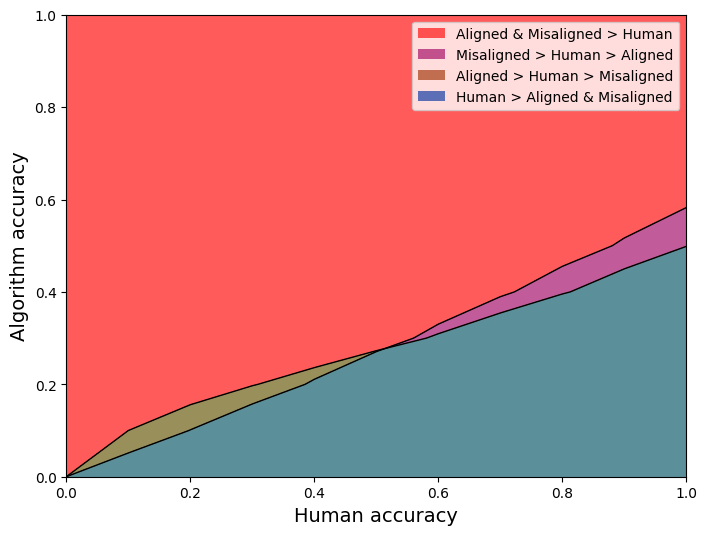

In [63]:
phi_h_vals = np.arange(0, 1.1, 0.1)
phi_a_vals = np.arange(0, 1.1, 0.1)
Phi_h, Phi_a = np.meshgrid(phi_h_vals, phi_a_vals)

Z1 = np.zeros_like(Phi_h)
Z2 = np.zeros_like(Phi_h)

for i in range(Phi_h.shape[0]):
    for j in range(Phi_h.shape[1]):
        phi_h = Phi_h[i, j]
        phi_a = Phi_a[i, j]

        D_h = Mallows(m, phi_h, pi_h)
        D_a1 = Mallows(m, phi_a, pi_a_aligned)
        D_a2 = Mallows(m, phi_a, pi_a_misaligned)

        utility1 = utility_joint_system1(D_h, D_a1, k, u)
        utility2 = utility_joint_system1(D_h, D_a2, k, u)

        human_utility = utilities_human([D_h], u)

        Z1[i, j] = utility1 - human_utility[0]
        Z2[i, j] = utility2 - human_utility[0]

plt.figure(figsize=(8, 6))
plt.xlabel('Human accuracy', fontsize=14)
plt.ylabel('Algorithm accuracy', fontsize=14)
# plt.title('Joint System Utility Regions', fontsize=16)

plt.contourf(Phi_h, Phi_a, Z1, levels=[-np.inf, 0, np.inf], colors=['blue', 'red'], alpha=0.4)
plt.contourf(Phi_h, Phi_a, Z2, levels=[-np.inf, 0, np.inf], colors=['green', 'red'], alpha=0.4)

contour1 = plt.contour(Phi_h, Phi_a, Z1, levels=[0], colors='black', linewidths=1)
contour2 = plt.contour(Phi_h, Phi_a, Z2, levels=[0], colors='black', linewidths=1)

plt.xlim(0, 1)
plt.ylim(0, 1)
# plt.legend(handles=[
#     mpatches.Patch(color='red', alpha=0.4, label='Joint > Human'),
#     mpatches.Patch(color='blue', alpha=0.4, label='Joint <= Human')
# ], loc='upper right')
legend_handles = [
    overlay_patch("red", "red", label="Aligned & Misaligned > Human"),
    overlay_patch("red", "blue", label="Misaligned > Human > Aligned"),
    overlay_patch("red", "green", label="Aligned > Human > Misaligned"),
    overlay_patch("blue", "green", label="Human > Aligned & Misaligned"),
]
plt.legend(handles=legend_handles, loc='upper right')
# plt.grid()
# plt.show()
plt.savefig('align-misalign.pdf', dpi=700)


In [89]:
def read_soi_file(filepath):
    metadata = {}
    rankings = []

    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            if line.startswith("#"):
                key_value = line[1:].strip()
                if ":" in key_value:
                    key, value = key_value.split(":", 1)
                    metadata[key.strip()] = value.strip()
                continue
            if ":" in line:
                user_id, prefs = line.split(":", 1)
                prefs = [int(x) for x in prefs.split(",") if x.strip().isdigit()]
                rankings.append((int(user_id), prefs))

    return metadata, rankings

metadata, rankings = read_soi_file("dataset/sushi/00014-00000001.soc")

In [ ]:
# merge the rankings 
merged_rankings = {}
for voter_count, prefs in rankings:
    prefs_tuple = tuple(p for p in prefs if p in {1, 2, 3, 4, 5})
    if prefs_tuple in merged_rankings:
        merged_rankings[prefs_tuple] += voter_count
    else:
        merged_rankings[prefs_tuple] = voter_count
rankings = [(voter_count, list(prefs)) for prefs, voter_count in merged_rankings.items()]

rankings.sort(key=lambda x: x[0], reverse=True)

Dhs = []
populations = []
m = 5
for population, ranking in rankings:
    print(ranking)
    populations.append(population)
    Dhs.append(Mallows(m, 1, ranking))
# normalize populations
populations = populations / np.sum(populations)
print(populations)


[4, 5, 2, 1, 3]
[4, 5, 1, 2, 3]
[4, 5, 2, 3, 1]
[2, 3, 1, 5, 4]
[2, 1, 3, 5, 4]
[1, 2, 3, 5, 4]
[5, 2, 3, 1, 4]
[5, 4, 1, 2, 3]
[1, 4, 5, 2, 3]
[4, 1, 5, 2, 3]
[2, 3, 1, 4, 5]
[4, 2, 5, 3, 1]
[3, 2, 1, 5, 4]
[5, 2, 1, 3, 4]
[5, 4, 2, 1, 3]
[2, 5, 3, 1, 4]
[2, 5, 1, 3, 4]
[1, 2, 3, 4, 5]
[5, 4, 2, 3, 1]
[4, 5, 1, 3, 2]
[2, 5, 4, 3, 1]
[2, 3, 5, 1, 4]
[4, 5, 3, 2, 1]
[5, 2, 3, 4, 1]
[2, 1, 3, 4, 5]
[5, 1, 2, 3, 4]
[4, 1, 5, 3, 2]
[1, 2, 4, 5, 3]
[1, 3, 2, 5, 4]
[4, 2, 5, 1, 3]
[4, 1, 2, 5, 3]
[2, 1, 5, 4, 3]
[3, 1, 2, 5, 4]
[2, 4, 5, 1, 3]
[2, 3, 5, 4, 1]
[1, 2, 5, 3, 4]
[2, 1, 5, 3, 4]
[1, 5, 2, 3, 4]
[1, 4, 2, 5, 3]
[4, 2, 3, 5, 1]
[2, 1, 4, 5, 3]
[1, 3, 2, 4, 5]
[1, 2, 5, 4, 3]
[5, 3, 2, 1, 4]
[2, 5, 4, 1, 3]
[2, 4, 5, 3, 1]
[2, 3, 4, 5, 1]
[1, 5, 4, 2, 3]
[4, 5, 3, 1, 2]
[2, 5, 3, 4, 1]
[4, 1, 2, 3, 5]
[5, 1, 4, 2, 3]
[1, 4, 5, 3, 2]
[3, 2, 1, 4, 5]
[4, 1, 3, 2, 5]
[5, 4, 3, 2, 1]
[4, 2, 1, 3, 5]
[3, 2, 5, 4, 1]
[4, 2, 1, 5, 3]
[1, 5, 3, 2, 4]
[5, 2, 1, 4, 3]
[3, 1, 5, 2, 4]
[5, 2, 4

In [ ]:
# traverse all permutations
perms = list(itertools.permutations(range(1, m + 1)))
i = 0
u = [m - i for i in range(m)]

utilitarian_welfares_of_max_utilitarian = []
utilitarian_welfares_of_max_uplift = []
uplift_percentages_of_max_utilitarian = []
uplift_percentages_of_max_uplift = []

phi_a = 10
for _ in range(5):
    max_expected_utility = -float('inf')
    max_uplift = -float('inf')
    max_utilitarian_algo = None
    max_uplift_algo = None

# for phi_a in np.arange(10, 2.1, 0.1):
    for perm in perms:
        pi_a_misaligned = list(perm)
        D_a = Mallows(m, phi_a, pi_a_misaligned)
        human_utility = utilities_human(Dhs[:1], u)[0]
        utilities = utilities_joint_system1(Dhs, D_a, k, u)
        expected_utility = np.dot(populations, utilities)
        uplift_percentage = sum([populations[i] if utilities[i] > human_utility else 0 for i in range(len(utilities))])
        if expected_utility > max_expected_utility:
            max_expected_utility = expected_utility
            utilitarian_max_algo = pi_a_misaligned
        
        if uplift_percentage > max_uplift:
            max_uplift = uplift_percentage
            max_uplift_algo = pi_a_misaligned

    print("Max Expected Utility:", max_expected_utility)
    print("Utilitarian Max Algo:", utilitarian_max_algo)
    print("Max Uplift:", max_uplift)
    print("Max Uplift Algo:", max_uplift_algo)

    ## Utilitarian welfare comparison
    utilitarian_welfares_of_max_utilitarian.append(max_expected_utility)
    utilitarian_welfares_of_max_uplift.append(np.dot(populations, utilities_joint_system1(Dhs, Mallows(m, phi_a, max_uplift_algo), k, u)))
    ## Uplift percentage comparison
    uplift_percentages_of_max_utilitarian.append(sum([populations[i] if utilities_joint_system1([Dhs[i]], Mallows(m, phi_a, utilitarian_max_algo), k, u)[0] > utilities_human([Dhs[i]], u)[0]\
            else 0 for i in range(len(Dhs))]))
    uplift_percentages_of_max_uplift.append(max_uplift)
    
    print("-----")
    phi_a = phi_a / 2.0

print(utilitarian_welfares_of_max_utilitarian)
print(utilitarian_welfares_of_max_uplift)
print(uplift_percentages_of_max_utilitarian)
print(uplift_percentages_of_max_uplift)

Max Expected Utility: 4.120009016412994
Utilitarian Max Algo: [2, 4, 1, 5, 3]
Max Uplift: 0.699
Max Uplift Algo: [1, 2, 4, 3, 5]
-----
Max Expected Utility: 4.119871233127012
Utilitarian Max Algo: [2, 4, 1, 5, 3]
Max Uplift: 0.699
Max Uplift Algo: [1, 2, 4, 3, 5]
-----
Max Expected Utility: 4.117256993110654
Utilitarian Max Algo: [2, 4, 1, 5, 3]
Max Uplift: 0.6866
Max Uplift Algo: [1, 2, 4, 5, 3]
-----
Max Expected Utility: 4.098304498494211
Utilitarian Max Algo: [2, 4, 1, 5, 3]
Max Uplift: 0.5139999999999999
Max Uplift Algo: [4, 2, 1, 3, 5]
-----
Max Expected Utility: 4.054003531924208
Utilitarian Max Algo: [2, 4, 1, 5, 3]
Max Uplift: 0.261
Max Uplift Algo: [4, 5, 2, 1, 3]
-----
[4.120009016412994, 4.119871233127012, 4.117256993110654, 4.098304498494211, 4.054003531924208]
[4.119997963446064, 4.1182372170791295, 4.113936282682758, 4.07426822723097, 4.027958812807974]
[0.699, 0.699, 0.6807999999999998, 0.5104, 0.23839999999999997]
[0.699, 0.699, 0.6866, 0.5139999999999999, 0.261]


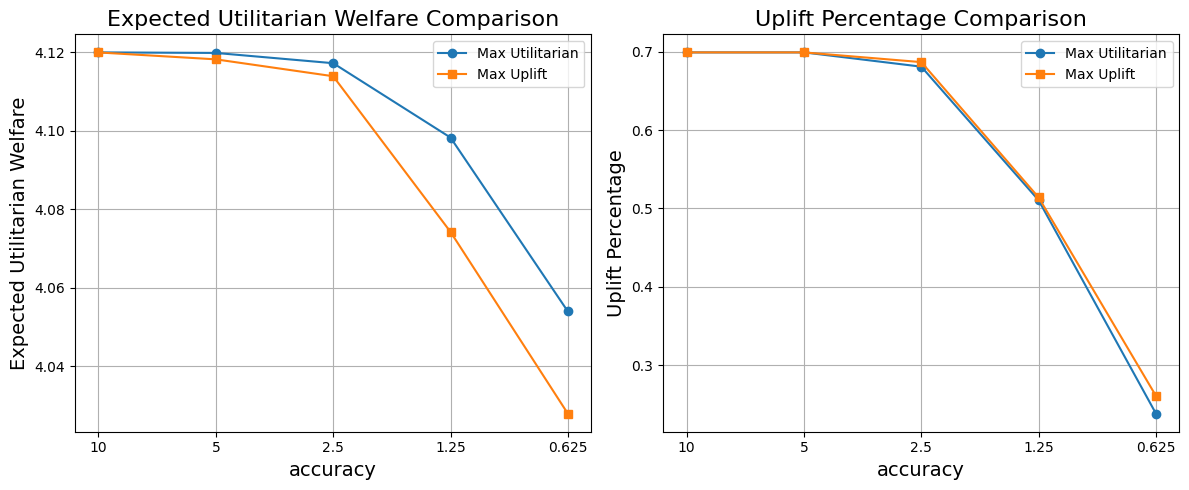

In [116]:
utilitarian_welfares_of_max_utilitarian = [4.120009016412994, 4.119871233127012, 4.117256993110654, 4.098304498494211, 4.054003531924208]
utilitarian_welfares_of_max_uplift = [4.119997963446064, 4.1182372170791295, 4.113936282682758, 4.07426822723097, 4.027958812807974]
uplift_percentages_of_max_utilitarian = [0.699, 0.699, 0.6807999999999998, 0.5104, 0.23839999999999997]
uplift_percentages_of_max_uplift = [0.699, 0.699, 0.6866, 0.5139999999999999, 0.261]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
# set xticks to be 0, 1, 2, 3, 4
plt.xticks(ticks=range(5), labels=[10, 5, 2.5, 1.25, 0.625])
plt.plot(utilitarian_welfares_of_max_utilitarian, marker='o', label='Max Utilitarian')
plt.plot(utilitarian_welfares_of_max_uplift, marker='s', label='Max Uplift')
plt.xlabel('accuracy', fontsize=14)
plt.ylabel('Expected Utilitarian Welfare', fontsize=14)
plt.title('Expected Utilitarian Welfare Comparison', fontsize=16)
plt.legend()
plt.grid()
plt.subplot(1, 2, 2)
plt.xticks(ticks=range(5), labels=[10, 5, 2.5, 1.25, 0.625])
plt.plot(uplift_percentages_of_max_utilitarian, marker='o', label='Max Utilitarian')
plt.plot(uplift_percentages_of_max_uplift, marker='s', label='Max Uplift')
plt.xlabel('accuracy', fontsize=14)
plt.ylabel('Uplift Percentage', fontsize=14)    
plt.title('Uplift Percentage Comparison', fontsize=16)
plt.legend()
plt.grid()
plt.tight_layout()
# plt.show()
# plt.savefig('utilitarian-uplift-comparison.pdf', dpi=700)

In [118]:
# traverse all permutations
perms = list(itertools.permutations(range(1, m + 1)))
i = 0
u = [m - i for i in range(m)]

utilitarian_welfares_of_max_utilitarian = []
utilitarian_welfares_of_max_uplift = []
uplift_percentages_of_max_utilitarian = []
uplift_percentages_of_max_uplift = []

phi_a = 10
for _ in range(5):
    max_expected_utility = -float('inf')
    max_uplift = -float('inf')
    max_utilitarian_algo = None
    max_uplift_algo = None

# for phi_a in np.arange(10, 2.1, 0.1):
    for perm in perms:
        pi_a_misaligned = list(perm)
        D_a = Mallows(m, phi_a, pi_a_misaligned)
        human_utility = utilities_human(Dhs[:1], u)[0]
        utilities = utilities_joint_system1(Dhs, D_a, k, u)
        expected_utility = np.dot(populations, utilities)
        uplift_percentage = sum([1 if utilities[i] > human_utility else 0 for i in range(len(utilities))]) 
        if expected_utility > max_expected_utility:
            max_expected_utility = expected_utility
            utilitarian_max_algo = pi_a_misaligned
        
        if uplift_percentage > max_uplift:
            max_uplift = uplift_percentage
            max_uplift_algo = pi_a_misaligned

    print("Max Expected Utility:", max_expected_utility)
    print("Utilitarian Max Algo:", utilitarian_max_algo)
    print("Max Uplift:", max_uplift)
    print("Max Uplift Algo:", max_uplift_algo)

    ## Utilitarian welfare comparison
    utilitarian_welfares_of_max_utilitarian.append(max_expected_utility)
    utilitarian_welfares_of_max_uplift.append(np.dot(populations, utilities_joint_system1(Dhs, Mallows(m, phi_a, max_uplift_algo), k, u)))
    ## Uplift percentage comparison
    uplift_percentages_of_max_utilitarian.append(sum([1 if utilities_joint_system1([Dhs[i]], Mallows(m, phi_a, utilitarian_max_algo), k, u)[0] > utilities_human([Dhs[i]], u)[0]\
            else 0 for i in range(len(Dhs))]))
    uplift_percentages_of_max_uplift.append(max_uplift)
    
    print("-----")
    phi_a = phi_a / 2.0

print(utilitarian_welfares_of_max_utilitarian)
print(utilitarian_welfares_of_max_uplift)
print(uplift_percentages_of_max_utilitarian)
print(uplift_percentages_of_max_uplift)
# ## Utilitarian welfare comparison
# D_a_max_uplift = Mallows(m, phi_a, max_uplift_algo)
# D_a_utilitarian = Mallows(m, phi_a, utilitarian_max_algo)
# expected_utility_of_max_uplift_algo = np.dot(populations, utilities_joint_system1(Dhs, D_a_max_uplift, k, u))


# ## Uplift percentage comparison
# uplift_percentage_of_max_utilitarian_algo = sum([populations[i] if utilities_joint_system1([Dhs[i]], D_a_utilitarian, k, u)[0] > utilities_human([Dhs[i]], u)[0] else 0 for i in range(len(Dhs))])
# print("Expected Utilitarian welfare of Max Uplift Algo:", expected_utility_of_max_uplift_algo)
# print("Expected Utilitarian welfare of Max Utilitarian Algo:", max_expected_utility)
# print("Uplift Percentage of Max Uplift Algo:", max_uplift)
# print("Uplift Percentage of Max Utilitarian Algo:", uplift_percentage_of_max_utilitarian_algo)



Max Expected Utility: 4.120009016412994
Utilitarian Max Algo: [2, 4, 1, 5, 3]
Max Uplift: 72
Max Uplift Algo: [1, 2, 3, 4, 5]
-----
Max Expected Utility: 4.119871233127012
Utilitarian Max Algo: [2, 4, 1, 5, 3]
Max Uplift: 72
Max Uplift Algo: [1, 2, 3, 4, 5]
-----
Max Expected Utility: 4.117256993110654
Utilitarian Max Algo: [2, 4, 1, 5, 3]
Max Uplift: 69
Max Uplift Algo: [1, 2, 3, 4, 5]
-----
Max Expected Utility: 4.098304498494211
Utilitarian Max Algo: [2, 4, 1, 5, 3]
Max Uplift: 48
Max Uplift Algo: [1, 2, 3, 4, 5]
-----
Max Expected Utility: 4.054003531924208
Utilitarian Max Algo: [2, 4, 1, 5, 3]
Max Uplift: 23
Max Uplift Algo: [1, 2, 3, 4, 5]
-----
[4.120009016412994, 4.119871233127012, 4.117256993110654, 4.098304498494211, 4.054003531924208]
[3.8570307520506, 3.8587899664711927, 3.878293233644241, 3.9234197792093966, 3.9546628259730197]
[72, 72, 69, 48, 23]
[72, 72, 69, 48, 23]


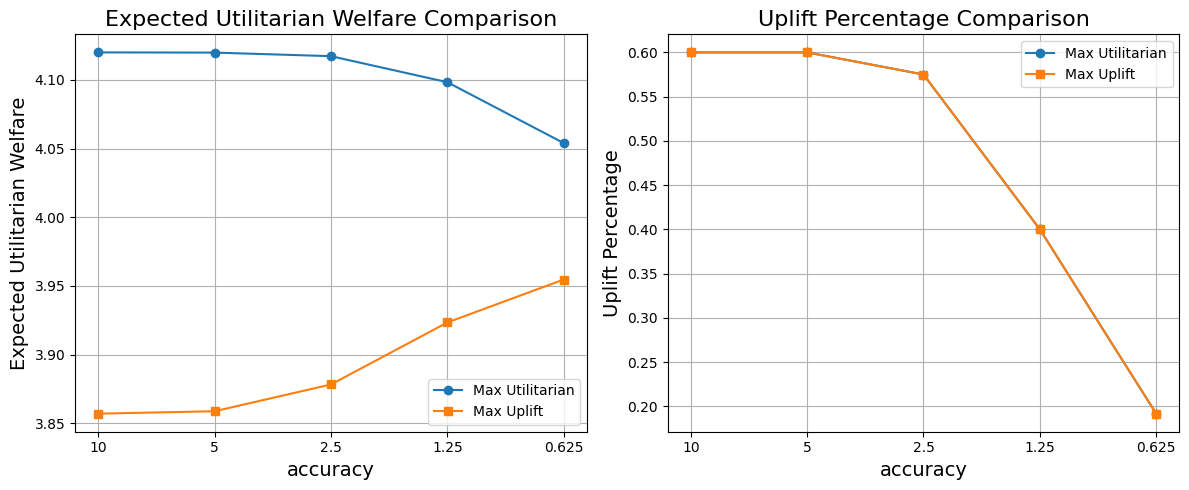

In [117]:
utilitarian_welfares_of_max_utilitarian = [4.120009016412994, 4.119871233127012, 4.117256993110654, 4.098304498494211, 4.054003531924208]
utilitarian_welfares_of_max_uplift =  [3.8570307520506, 3.8587899664711927, 3.878293233644241, 3.9234197792093966, 3.9546628259730197]
uplift_percentages_of_max_utilitarian = [0.6, 0.6, 0.575, 0.4, 0.19166666666666668]
uplift_percentages_of_max_uplift = [0.6, 0.6, 0.575, 0.4, 0.19166666666666668]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
# set xticks to be 0, 1, 2, 3, 4
plt.xticks(ticks=range(5), labels=[10, 5, 2.5, 1.25, 0.625])
plt.plot(utilitarian_welfares_of_max_utilitarian, marker='o', label='Max Utilitarian')
plt.plot(utilitarian_welfares_of_max_uplift, marker='s', label='Max Uplift')
plt.xlabel('accuracy', fontsize=14)
plt.ylabel('Expected Utilitarian Welfare', fontsize=14)
plt.title('Expected Utilitarian Welfare Comparison', fontsize=16)
plt.legend()
plt.grid()
plt.subplot(1, 2, 2)
plt.xticks(ticks=range(5), labels=[10, 5, 2.5, 1.25, 0.625])
plt.plot(uplift_percentages_of_max_utilitarian, marker='o', label='Max Utilitarian')
plt.plot(uplift_percentages_of_max_uplift, marker='s', label='Max Uplift')
plt.xlabel('accuracy', fontsize=14)
plt.ylabel('Uplift Percentage', fontsize=14)    
plt.title('Uplift Percentage Comparison', fontsize=16)
plt.legend()
plt.grid()
plt.tight_layout()
# plt.show()
# plt.savefig('utilitarian-uplift-comparison.pdf', dpi=700)